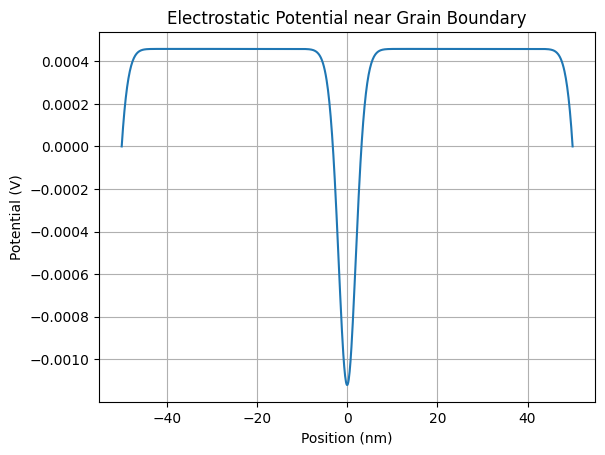

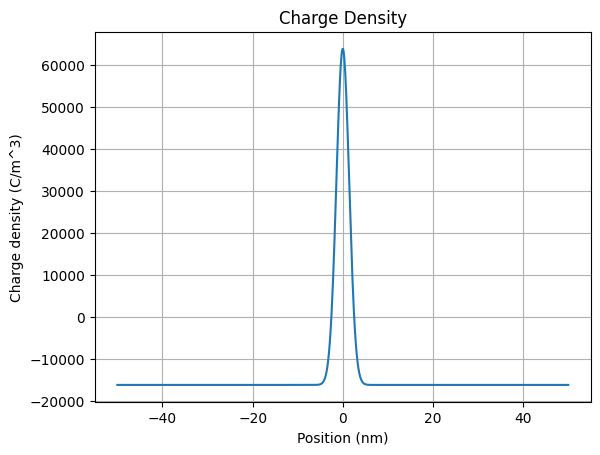

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
q = 1.602e-19       # C
kB = 1.381e-23      # J/K
T = 800             # K (typical for oxides)
eps0 = 8.85e-12
eps_r = 10
eps = eps_r * eps0

# Domain
L = 50e-9      # 50 nm
Nx = 1000
x = np.linspace(-L, L, Nx)
dx = x[1] - x[0]

# Bulk properties
n0 = 1e21           # m^-3
p0 = 1e15           # m^-3

# Defect densities (example: acceptor-type GB)
NA_bulk = 1e23      # m^-3
ND_bulk = 0

# Grain boundary: extra localized charge
gb_width = 2e-9
gb_charge = -5e23   # m^-3 (extra negative charge)

def grain_boundary_profile(x):
    return gb_charge * np.exp(-(x/gb_width)**2)

# Initial potential
phi = np.zeros(Nx)

# Iteration parameters
max_iter = 5000
mixing = 0.1

for it in range(max_iter):

    # Carrier densities
    n = n0 * np.exp(q * phi / (kB * T))
    p = p0 * np.exp(-q * phi / (kB * T))

    # Defect charge (simplified: fully ionized)
    NA = NA_bulk + grain_boundary_profile(x)
    ND = ND_bulk

    rho = q * (ND - NA + p - n)

    # Solve Poisson (finite difference)
    phi_new = np.copy(phi)

    for i in range(1, Nx-1):
        phi_new[i] = 0.5 * (phi[i+1] + phi[i-1] + dx**2 * (-rho[i]/eps))

    # Boundary conditions: neutral bulk
    phi_new[0] = 0
    phi_new[-1] = 0

    # Mixing for stability
    phi = (1 - mixing) * phi + mixing * phi_new

    # Convergence check
    if np.max(np.abs(phi_new - phi)) < 1e-6:
        print(f"Converged in {it} iterations")
        break

# Plot
plt.figure()
plt.plot(x*1e9, phi)
plt.xlabel("Position (nm)")
plt.ylabel("Potential (V)")
plt.title("Electrostatic Potential near Grain Boundary")
plt.grid()

plt.figure()
plt.plot(x*1e9, rho)
plt.xlabel("Position (nm)")
plt.ylabel("Charge density (C/m^3)")
plt.title("Charge Density")
plt.grid()

plt.show()
